# Multivariate Time Series Cheat Sheet
Quick, copy-pasteable reference for cross-correlation, ARIMAX, and VAR modeling in Python.
Run top to bottom once to load the demo data used by every snippet below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.signal import correlate
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX

rng = np.random.default_rng(0)
n = 300
noise = rng.normal(size=n)
x = pd.Series(np.convolve(noise, np.ones(3)/3, mode='same')).cumsum() * 0  # placeholder unused
# Demo bivariate series: y2 is a noisy, lagged copy of y1
y1 = pd.Series(rng.normal(size=n)).rolling(3, min_periods=1).mean()
y2 = y1.shift(3).fillna(0) * 0.8 + rng.normal(scale=0.3, size=n)
demo = pd.DataFrame({'y1': y1, 'y2': y2})
demo.head()


,y1,y2
0,1.203259,-0.347049
1,0.920166,-0.409464
2,0.799557,-0.069368
3,-0.858954,1.645857
4,-0.984435,0.819395


## 1. Cross-correlation function (CCF)

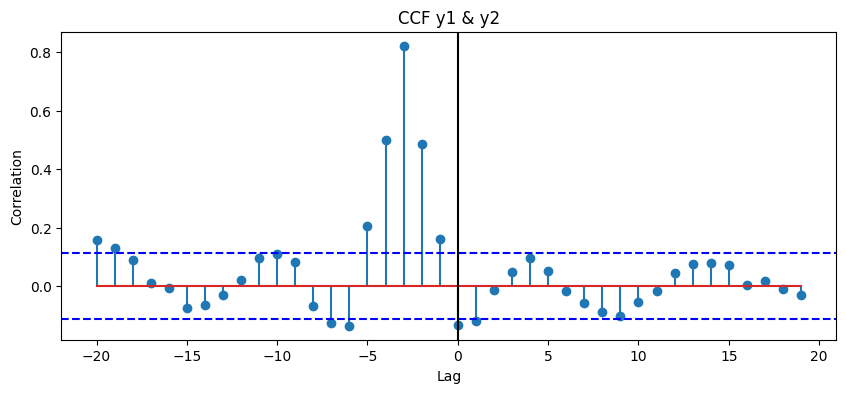

Significant lags: [-20, -19, -7, -6, -5, -4, -3, -2, -1, 0, 1]


In [2]:
def plot_ccf(data_a, data_b, lag_lookback, percentile=95, ax=None, title=None):
    """Cross-correlation of data_a and data_b out to +/- lag_lookback,
    with a significance band at the given percentile."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    n = len(data_a)
    ccf = correlate(data_a - np.mean(data_a), data_b - np.mean(data_b),
                     method='direct') / (np.std(data_a) * np.std(data_b) * n)
    mid = (len(ccf) - 1) // 2
    lags = np.arange(-lag_lookback, lag_lookback)
    vals = ccf[mid - lag_lookback: mid + lag_lookback]
    z = {90: 1.645, 95: 1.96, 99: 2.576}[percentile]
    band = z / np.sqrt(n)
    ax.stem(lags, vals, markerfmt='o')
    ax.axhline(band, color='b', ls='--')
    ax.axhline(-band, color='b', ls='--')
    ax.axvline(0, color='black', ls='-')
    ax.set_xlabel('Lag'); ax.set_ylabel('Correlation'); ax.set_title(title)
    return lags, vals

lags, vals = plot_ccf(demo['y1'], demo['y2'], lag_lookback=20, title='CCF y1 & y2')
plt.show()
sig = lags[np.abs(vals) > 1.96/np.sqrt(len(demo))]
print("Significant lags:", sig.tolist())

## 2. Stationarity checks

ADF stat=-3.012, p-value=0.0338
-> stationary


/tmp/ipykernel_633/3111160220.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(demo['y1'], autolag='AIC')


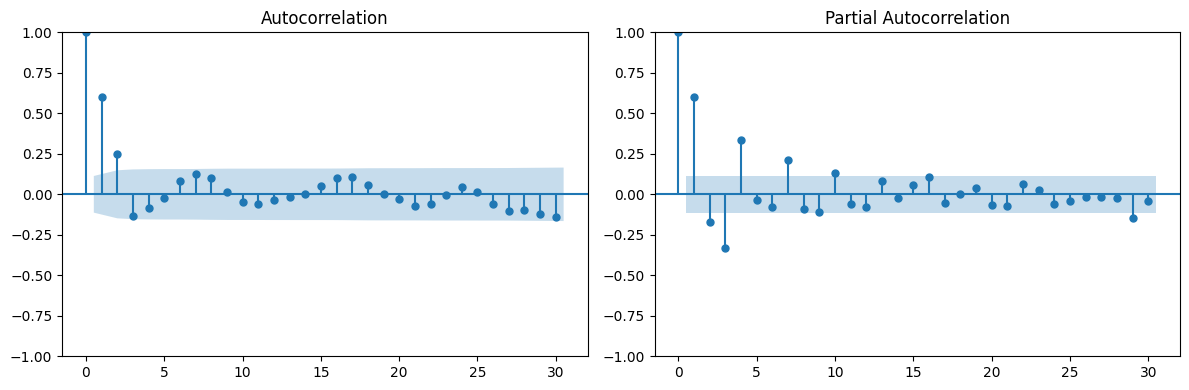

In [3]:
# ADF test: H0 = unit root present (non-stationary)
result = adfuller(demo['y1'], autolag='AIC')
print(f"ADF stat={result[0]:.3f}, p-value={result[1]:.4f}")
print("-> stationary" if result[1] < 0.05 else "-> non-stationary, consider differencing")

# First-difference if needed
diffed = demo['y1'].diff().dropna()

# ACF / PACF for order selection
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(demo['y1'], lags=30, ax=ax[0])
plot_pacf(demo['y1'], lags=30, ax=ax[1], method='ywm')
plt.tight_layout(); plt.show()

## 3. Building lagged exogenous features (for ARIMAX)

In [4]:
# Shift a covariate backward so that the exogenous column at row t
# holds the covariate value from `lag` steps earlier: shift(-lag)
def make_lag(series, lag):
    return series.shift(-lag)

X = pd.DataFrame({
    'y2_lag3': make_lag(demo['y2'], 3),
    'y2_lag7': make_lag(demo['y2'], 7),
}).dropna()
y = demo['y1'].loc[X.index]
X.head()

,y2_lag3,y2_lag7
0,1.645857,-0.552653
1,0.819395,-1.346151
2,0.868522,-0.105650
3,-0.623348,-0.135746
4,-0.552653,-0.197977


## 4. ARIMAX / SARIMAX with statsmodels

In [5]:
train_size = int(len(y) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

model = SARIMAX(y_train, exog=X_train, order=(1, 0, 0),
                 enforce_stationarity=True, enforce_invertibility=True)
fit = model.fit(disp=False)
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                     y1   No. Observations:                  234
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -38.857
Date:                Sat, 29 Aug 2026   AIC                             85.715
Time:                        01:55:28   BIC                             99.536
Sample:                             0   HQIC                            91.287
                                - 234                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y2_lag3        0.7578      0.043     17.548      0.000       0.673       0.842
y2_lag7        0.0029      0.044      0.065      0.948      -0.083       0.089
ar.L1          0.2755      0.061      4.493      0.0

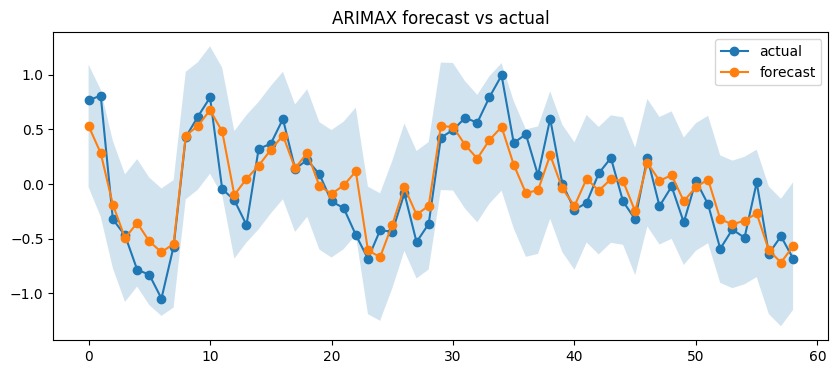

MSE: 0.05883255625714826


In [6]:
forecast = fit.get_forecast(steps=len(y_test), exog=X_test)
pred = forecast.predicted_mean
ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test.values, marker='o', label='actual')
ax.plot(pred.values, marker='o', label='forecast')
ax.fill_between(range(len(pred)), ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2)
ax.legend(); ax.set_title('ARIMAX forecast vs actual')
plt.show()

from sklearn.metrics import mean_squared_error
print("MSE:", mean_squared_error(y_test, pred))

## 5. ARIMAX with pmdarima (`auto_arima` + p-value pruning)

In [7]:
# import pmdarima as pm
#
# arima = pm.auto_arima(y_train, X_train, error_action='ignore',
#                        suppress_warnings=True, seasonal=False, trace=True)
#
# pvalues = arima.pvalues()
# X_selected = X_train.copy()
# while (pvalues > 0.05).any():
#     drop_col = pvalues.idxmax()
#     X_selected = X_selected.drop(columns=[drop_col])
#     arima = pm.auto_arima(y_train, X_selected, error_action='ignore',
#                            suppress_warnings=True, seasonal=False)
#     pvalues = arima.pvalues()
# print(arima.summary())
print("Uncomment above if pmdarima is installed (pip install pmdarima).")

Uncomment above if pmdarima is installed (pip install pmdarima).


## 6. Variance Inflation Factor (multicollinearity check)

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(X):
    Xc = sm.add_constant(X)
    return pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=X.columns, name='VIF'
    )

vif_table(X_train)

y2_lag3    1.034764
y2_lag7    1.034764
Name: VIF, dtype: float64

## 7. VAR / VARMAX with statsmodels

In [9]:
var_data = pd.DataFrame({
    'a': demo['y1'].diff().dropna().values,
    'b': demo['y2'].diff().dropna().values,
})

best_aic, best_order = np.inf, None
for p in range(1, 4):
    for q in range(0, 2):
        try:
            m = VARMAX(var_data, order=(p, q), trend='c',
                       enforce_stationarity=True, enforce_invertibility=True)
            r = m.fit(disp=False)
            if r.aic < best_aic:
                best_aic, best_order = r.aic, (p, q)
        except Exception:
            continue
print("Best (p, q) by AIC:", best_order, "AIC:", best_aic)

var_model = VARMAX(var_data, order=best_order, trend='c',
                    enforce_stationarity=True, enforce_invertibility=True)
var_fit = var_model.fit(disp=False)
print(var_fit.summary())

/tmp/ipykernel_633/1564441886.py:10: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend='c',


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_633/1564441886.py:10: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend='c',


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/tmp/ipykernel_633/1564441886.py:10: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  m = VARMAX(var_data, order=(p, q), trend='c',


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_633/1564441886.py:19: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  var_model = VARMAX(var_data, order=best_order, trend='c',


Best (p, q) by AIC: (3, 1) AIC: 409.24624401827435


                           Statespace Model Results                           
Dep. Variable:             ['a', 'b']   No. Observations:                  299
Model:                     VARMA(3,1)   Log Likelihood                -183.623
                          + intercept   AIC                            409.246
Date:                Sat, 29 Aug 2026   BIC                            486.956
Time:                        01:55:31   HQIC                           440.349
Sample:                             0                                         
                                - 299                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):             0.11, 0.00   Jarque-Bera (JB):           4.35, 0.31
Prob(Q):                        0.74, 0.99   Prob(JB):                   0.11, 0.86
Heteroskedasticity (H):         1.05, 0.57   Skew:                      -0.29, 0.01
Prob(H) (two-sided):            0.80,

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


## 8. VAR forecasting

In [10]:
h = 10
fc_obj = var_fit.get_forecast(steps=h)
fc_mean = fc_obj.predicted_mean          # one column per variable in the system
fc_ci = fc_obj.conf_int(alpha=0.05)      # columns: "lower <var>", "upper <var>"
fc_mean.head()

# summary_frame(endog=i) gives mean/se/ci for just the i-th variable (0-indexed):
fc_obj.summary_frame(endog=0, alpha=0.05).head()

a,mean,mean_se,mean_ci_lower,mean_ci_upper
299,0.541043,0.382383,-0.208414,1.290500
300,0.283893,0.386540,-0.473712,1.041499
301,-0.149925,0.388207,-0.910797,0.610947
302,-0.244445,0.464497,-1.154842,0.665952
303,-0.171232,0.471161,-1.094691,0.752228


## 9. Granger causality

In [11]:
# H0: column 2 does NOT Granger-cause column 1
# Note: the `verbose` kwarg was removed in newer statsmodels versions;
# if you're on an older version you can pass verbose=False to silence output.
gc = grangercausalitytests(var_data[['a', 'b']], maxlag=4)
for lag, res in gc.items():
    fstat, pval, _, _ = res[0]['ssr_ftest']
    print(f"lag={lag}: F={fstat:.3f}, p={pval:.4f}")

lag=1: F=4.538, p=0.0340
lag=2: F=2.207, p=0.1119
lag=3: F=7.797, p=0.0001
lag=4: F=5.097, p=0.0006


## 10. Impulse response function (VAR)

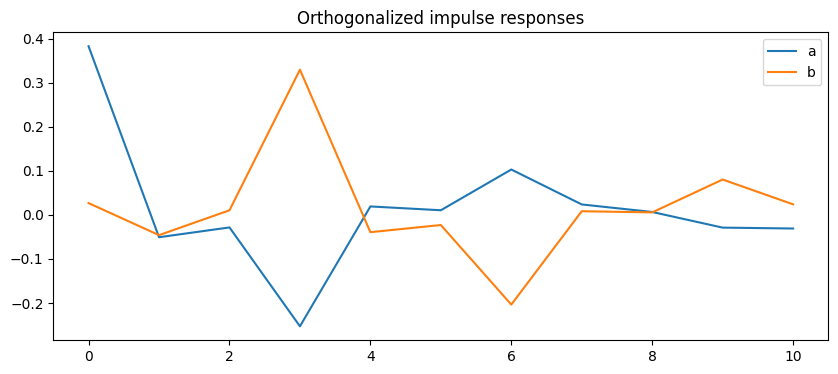

In [12]:
irf = var_fit.impulse_responses(steps=10, orthogonalized=True)
irf.plot(figsize=(10, 4), title='Orthogonalized impulse responses')
plt.show()

## 11. Quick reference table

| Task | Snippet |
|---|---|
| Stationarity test | `adfuller(series)`; p<0.05 → reject unit-root null |
| ACF/PACF | `plot_acf(series, lags=k)`, `plot_pacf(series, lags=k, method='ywm')` |
| CCF | `correlate(a - a.mean(), b - b.mean()) / (a.std()*b.std()*n)` |
| CCF significance band | `1.96/sqrt(n)` for 95% |
| Lag a covariate for ARIMAX | `series.shift(-lag)` |
| Fit ARIMAX | `SARIMAX(y, exog=X, order=(p,d,q)).fit()` |
| Fit VAR/VARMAX | `VARMAX(df, order=(p,q), trend='c').fit()` |
| Forecast + CI (single series) | `fit.get_forecast(steps=h[, exog=X_future]).summary_frame(alpha=0.05)` |
| Forecast + CI (VAR, multivariate) | use `.predicted_mean` (one column/var) and `.conf_int()` (`"lower <var>"`/`"upper <var>"` columns); `summary_frame(endog=i)` gives one variable at a time |
| Multicollinearity | `variance_inflation_factor(X.values, i)` |
| Granger causality | `grangercausalitytests(df[[y, x]], maxlag=k)` |
| Impulse response | `var_fit.impulse_responses(steps=h, orthogonalized=True)` |
